In [17]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from knn import Knn

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [ ]:
# My model
model = Knn()
model.fit(X_train, y_train)

my_y_pred = model.predict(X_test)

my_accuracy = accuracy_score(y_test, my_y_pred)
print(my_accuracy)

print(f'Accuracy: {my_accuracy * 100 :.2f}%')

1.0
Accuracy: 100.00%


In [20]:
# sklearn model
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

sk_y_pred = model.predict(X_test)

sk_accuracy = accuracy_score(y_test, sk_y_pred)
print(sk_accuracy)

print(f'Accuracy: {sk_accuracy * 100 :.2f}%')

1.0
Accuracy: 100.00%


In [21]:
print("=" * 45)
print(f"  {'Model':<25} {'Accuracy':>10}")
print(f"  {'-'*35}")
print(f"  {'Our KNN':<25} {my_accuracy:>9.4f}")
print(f"  {'Sklearn KNN':<25} {sk_accuracy:>9.4f}")
print("=" * 45)

if my_accuracy == sk_accuracy:
    print("\n  ✅ Implementations match!")

  Model                       Accuracy
  -----------------------------------
  Our KNN                      1.0000
  Sklearn KNN                  1.0000

  ✅ Implementations match!


In [22]:
# my KNN
my_report = classification_report(y_test, my_y_pred, target_names=iris.target_names)

# Sklearn KNN
sk_report = classification_report(y_test, sk_y_pred, target_names=iris.target_names)

print("Our KNN Classification Report")
print("=" * 50)
print(my_report)

print("Sklearn KNN Classification Report")
print("=" * 50)
print(sk_report)

Our KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Sklearn KNN Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



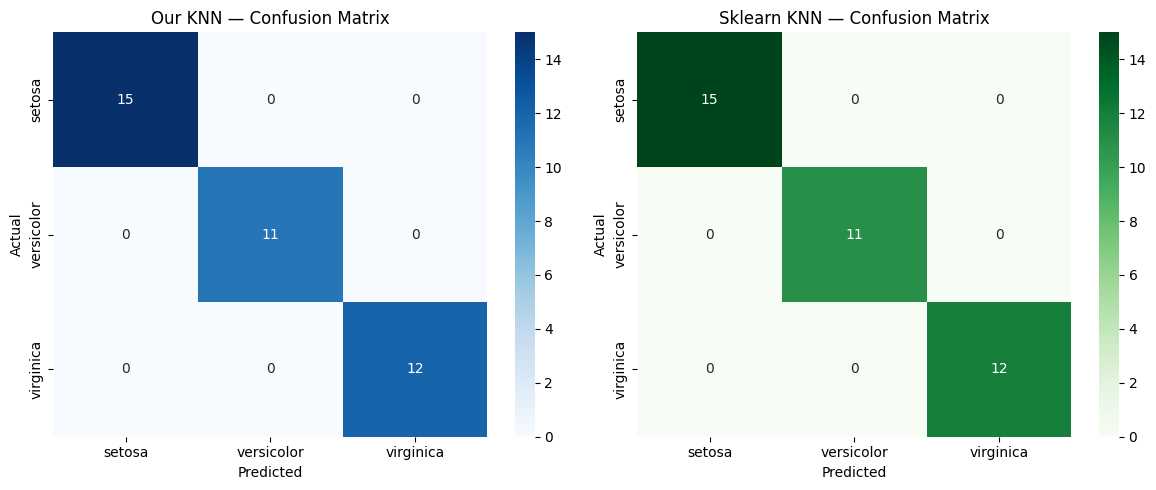

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# my KNN
cm_ours = confusion_matrix(y_test, my_y_pred)
sns.heatmap(
    cm_ours,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[0]
)
axes[0].set_title('Our KNN — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Sklearn KNN
cm_sk = confusion_matrix(y_test, sk_y_pred)
sns.heatmap(
    cm_sk,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names,
    ax=axes[1]
)
axes[1].set_title('Sklearn KNN — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

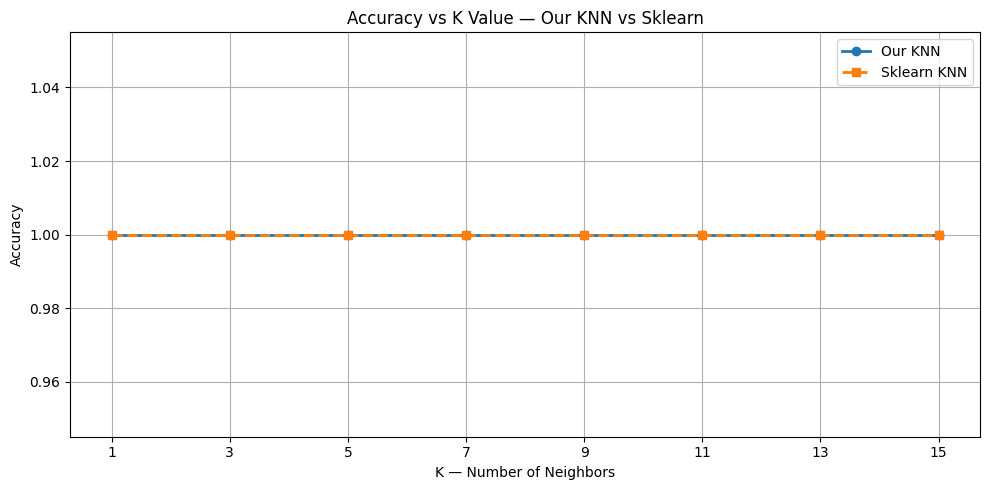

In [28]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
my_accuracies = []
sk_accuracies = []

for k in k_values:
    # my KNN
    my_model = Knn(k)
    my_model.fit(X_train, y_train)
    my_y_pred = my_model.predict(X_test)
    my_accuracies.append(accuracy_score(y_test, my_y_pred))

    # Sklearn KNN
    sk_model = KNeighborsClassifier(n_neighbors=k)
    sk_model.fit(X_train, y_train)
    sk_y_pred = sk_model.predict(X_test)
    sk_accuracies.append(accuracy_score(y_test, sk_y_pred))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, my_accuracies, marker='o', label='Our KNN', linewidth=2)
plt.plot(k_values, sk_accuracies, marker='s', label='Sklearn KNN', linewidth=2, linestyle='--')
plt.xlabel('K — Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value — Our KNN vs Sklearn')
plt.legend()
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()